In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from pathlib import Path
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache

# Import Architectural Style
import viz_style
viz_style.set_architectural_style()

# Setup Cache
output_dir = "../Dataset/RAW"
manifest_path = os.path.join(output_dir, "manifest.json")
cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)

print("Cache initialized.")

Architectural plot style applied (Dark Mode).
Cache initialized.


### Step 1: Session Selection
Filter sessions to find those with recordings in the Primary Visual Cortex (VISp) and other visual areas.

In [12]:
sessions = cache.get_session_table()
print(f"Total Sessions: {len(sessions)}")

# Filter for Brain Observatory 1.1 and VIS areas
VIS_Sessions = sessions[
    (sessions.ecephys_structure_acronyms.apply(lambda x: ('VISam' in x) and ('VISl' in x) and ('VISp' in x) and ('VISal' in x))) 
    & (sessions.session_type.apply(lambda x: 'brain_observatory_1.1' in x))
    & (sessions.probe_count == 6)
]

print(f"Sessions with full VIS coverage: {len(VIS_Sessions)}")
display(VIS_Sessions[['session_type', 'ecephys_structure_acronyms']].head())

Total Sessions: 58
Sessions with full VIS coverage: 12


,session_type,ecephys_structure_acronyms
id,,
719161530,brain_observatory_1.1,"[TH, Eth, APN, POL, LP, DG, CA1, VISpm, nan, N..."
721123822,brain_observatory_1.1,"[MB, SCig, PPT, NOT, DG, CA1, VISam, nan, LP, ..."
750332458,brain_observatory_1.1,"[grey, VISrl, nan, VISal, IntG, IGL, LGd, CA3,..."
750749662,brain_observatory_1.1,"[LP, DG, CA1, VISp, nan, LGd, CA3, VISrl, VPM,..."
754312389,brain_observatory_1.1,"[APN, POL, LP, DG, CA1, VISam, nan, LGd, HPF, ..."


### Step 2: Load Specific Session
We select Session **715093703** for detailed analysis.

In [13]:
session_id = 715093703
session = cache.get_session_data(session_id)
print(f"Session {session_id} loaded.")

print("\n--- Session Metadata ---")
print(session.metadata)

print("\n--- Unit Counts per Structure ---")
print(session.structurewise_unit_counts)

Session 715093703 loaded.

--- Session Metadata ---
{'specimen_name': 'Sst-IRES-Cre;Ai32-386129', 'session_type': 'brain_observatory_1.1', 'full_genotype': 'Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt', 'sex': 'M', 'age_in_days': 118.0, 'rig_equipment_name': 'NP.1', 'num_units': 884, 'num_channels': 2219, 'num_probes': 6, 'num_stimulus_presentations': 70388, 'session_start_time': datetime.datetime(2019, 1, 19, 0, 54, 18, tzinfo=tzoffset(None, -28800)), 'ecephys_session_id': 715093703, 'structure_acronyms': ['PO', 'PoT', 'LP', 'DG', 'CA1', 'VISp', nan, 'LGd', 'CA3', 'VISl', 'VISrl', 'grey', 'VISpm', 'VISam', 'APN', 'MB'], 'stimulus_names': ['spontaneous', 'gabors', 'flashes', 'drifting_gratings', 'natural_movie_three', 'natural_movie_one', 'static_gratings', 'natural_scenes']}

--- Unit Counts per Structure ---
CA1      145
LP       139
grey     117
LGd       82
PO        76
VISrl     76
VISp      60
VISpm     50
VISl      42
VISam     30
APN       26
DG        26
CA3       14
PoT    

### Step 3: Stimulus Inspection
Visualize the visual stimuli presented during the session.

Stimuli presented: ['spontaneous', 'gabors', 'flashes', 'drifting_gratings', 'natural_movie_three', 'natural_movie_one', 'static_gratings', 'natural_scenes']


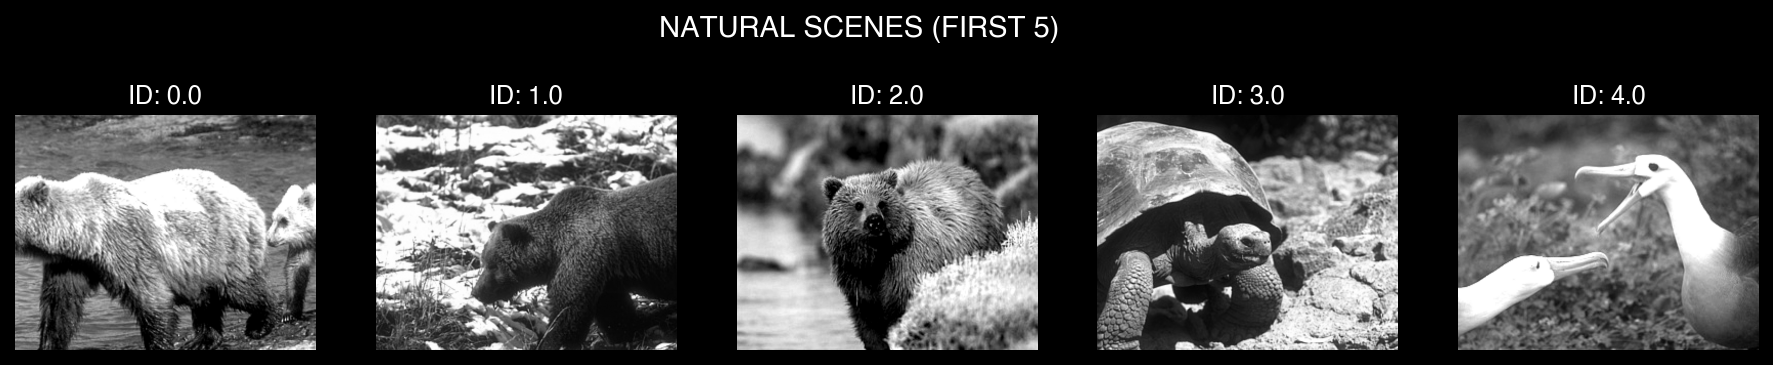


Natural Movie One: 900 frames


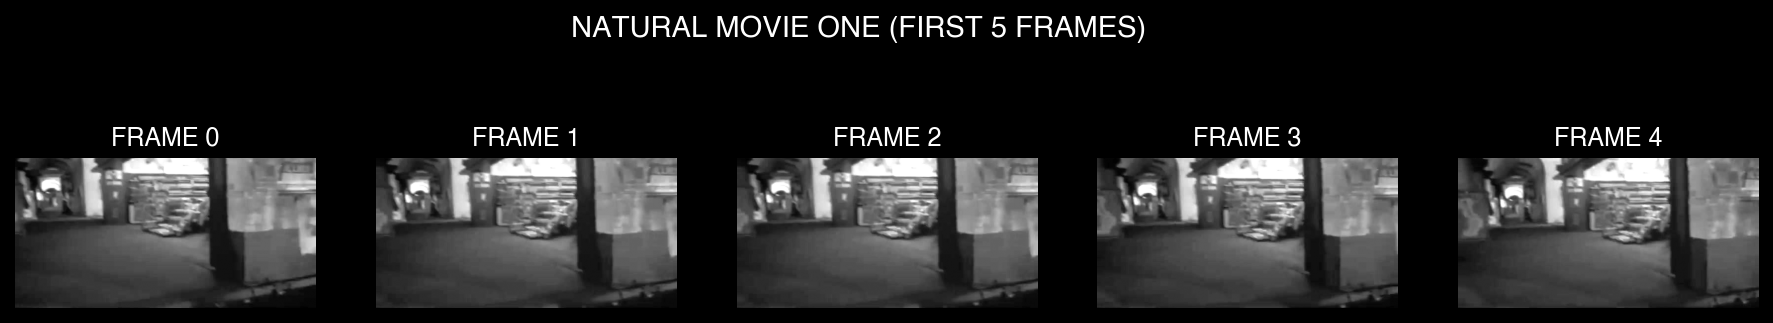

In [14]:
print(f"Stimuli presented: {session.stimulus_names}")

# Visualize Natural Scenes
if 'natural_scenes' in session.stimulus_names:
    table = session.get_stimulus_table('natural_scenes')
    unique_images = np.sort(table['frame'].unique())
    unique_images = unique_images[unique_images != -1]
    
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle("NATURAL SCENES (FIRST 5)", fontsize=14, color=viz_style.WHITE)
    for i, img_id in enumerate(unique_images[:5]):
        img = cache.get_natural_scene_template(img_id)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"ID: {img_id}", color=viz_style.WHITE)
        axes[i].axis('off')
    plt.show()

# Visualize Natural Movie One
if 'natural_movie_one' in session.stimulus_names:
    movie_template = cache.get_natural_movie_template(1)
    print(f"\nNatural Movie One: {movie_template.shape[0]} frames")
    
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle("NATURAL MOVIE ONE (FIRST 5 FRAMES)", fontsize=14, color=viz_style.WHITE)
    for i in range(5):
        axes[i].imshow(movie_template[i, :, :], cmap='gray')
        axes[i].set_title(f"FRAME {i}", color=viz_style.WHITE)
        axes[i].axis('off')
    plt.show()

### Step 4: NWB File Structure
Inspect the internal structure of the NWB file using `h5py`.

In [15]:
nwb_path = Path(output_dir) / f"session_{session_id}" / f"session_{session_id}.nwb"
print(f"Inspecting NWB file: {nwb_path}")

if nwb_path.exists():
    with h5py.File(nwb_path, 'r') as f:
        print("\n--- Root Keys ---")
        print(list(f.keys()))
        
        if 'processing' in f:
            print("\n--- Processing Modules ---")
            print(list(f['processing'].keys()))
else:
    print("NWB file not found locally.")

Inspecting NWB file: ../Dataset/RAW/session_715093703/session_715093703.nwb

--- Root Keys ---
['acquisition', 'analysis', 'file_create_date', 'general', 'identifier', 'intervals', 'processing', 'session_description', 'session_start_time', 'specifications', 'stimulus', 'timestamps_reference_time', 'units']

--- Processing Modules ---
['eye_tracking_rig_metadata', 'optotagging', 'running', 'stimulus']


### Step 5: Peristimulus Time Histograms (PSTH)
Analyze the temporal response of VISp units to the "flashes" stimulus.

Calculating PSTH for 60 VISp units during 'flashes'...


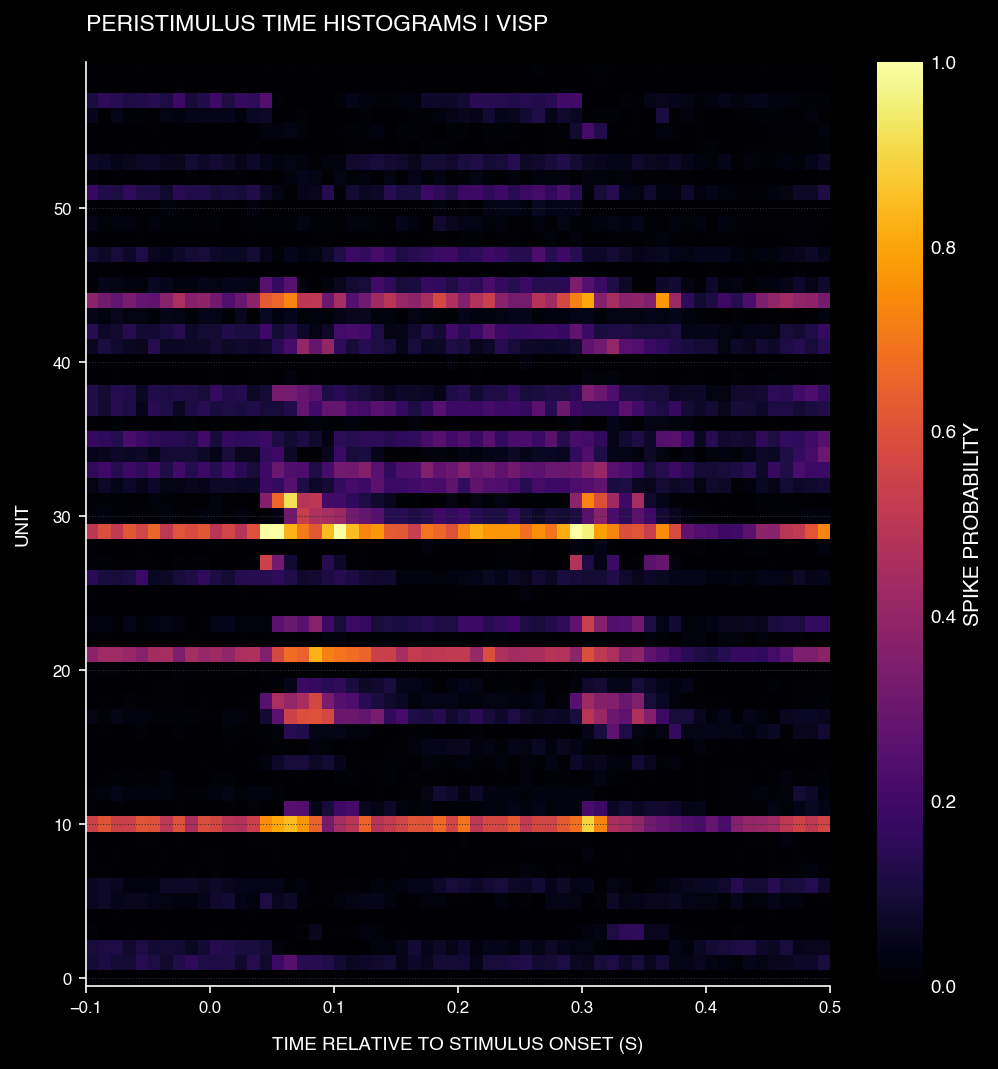

In [16]:
# Select VISp units
units = session.units[session.units["ecephys_structure_acronym"] == 'VISp']

# Check for 'flashes' stimulus
if 'flashes' in session.stimulus_names:
    presentations = session.get_stimulus_table("flashes")
    
    time_step = 0.01
    time_bins = np.arange(-0.1, 0.5 + time_step, time_step)

    print(f"Calculating PSTH for {len(units)} VISp units during 'flashes'...")
    histograms = session.presentationwise_spike_counts(
        stimulus_presentation_ids=presentations.index.values,  
        bin_edges=time_bins,
        unit_ids=units.index.values
    )

    mean_histograms = histograms.mean(dim="stimulus_presentation_id")

    fig, ax = plt.subplots(figsize=(8, 8))
    c = ax.pcolormesh(
        mean_histograms["time_relative_to_stimulus_onset"], 
        np.arange(mean_histograms["unit_id"].size),
        mean_histograms.T, 
        vmin=0,
        vmax=1,
        cmap='inferno'
    )

    viz_style.format_axis(
        ax, 
        title="PERISTIMULUS TIME HISTOGRAMS | VISp",
        xlabel="TIME RELATIVE TO STIMULUS ONSET (S)",
        ylabel="UNIT"
    )

    # Colorbar
    cbar = plt.colorbar(c, ax=ax, label="Spike Probability")
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(size=0, colors=viz_style.WHITE)
    cbar.set_label("SPIKE PROBABILITY", color=viz_style.WHITE)

    plt.show()
else:
    print("Stimulus 'flashes' not found in this session.")

### Step 6: Neural Response Matrix
Construct a (Frames x Neurons) response matrix for "Natural Movie One".
1. **Subset**: First 50 neurons.
2. **Depth Sorted**: Neurons sorted by cortical depth.

Selected 60 units from VISp
Total Presentations (Frames x Repeats): 18000
Time Window per Frame: 0.0334 s
Calculating spike counts... (this may take a moment)

--- Final Response Matrix Created ---
Shape: (900, 60) (Frames x Neurons)

--- Final Response Matrix Created ---
Shape: (900, 60) (Frames x Neurons)


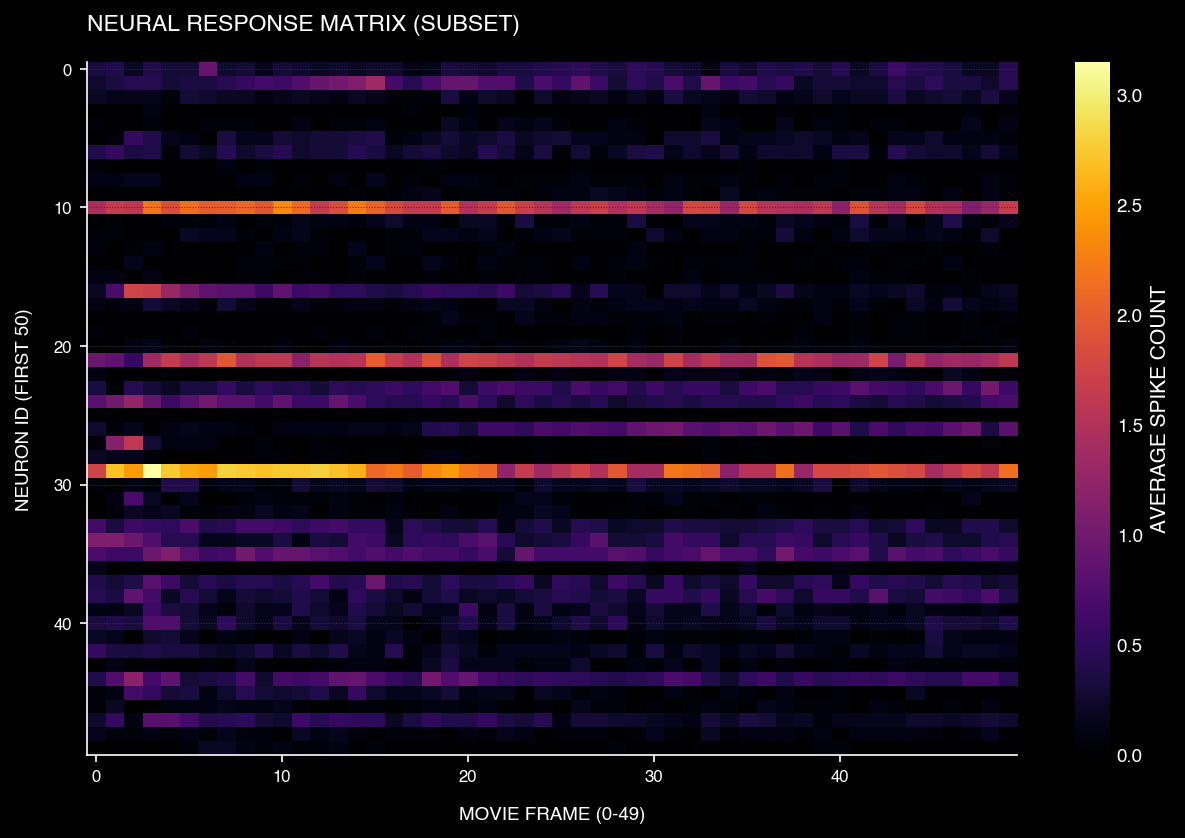

In [17]:
# Neural Response Matrix for Natural Movie One
if 'natural_movie_one' in session.stimulus_names:
    visp_units = session.units[session.units["ecephys_structure_acronym"] == "VISp"]
    print(f"Selected {len(visp_units)} units from VISp")

    movie_table = session.get_stimulus_table("natural_movie_one")
    print(f"Total Presentations (Frames x Repeats): {len(movie_table)}")

    frame_duration = movie_table['duration'].mean()
    print(f"Time Window per Frame: {frame_duration:.4f} s")

    print("Calculating spike counts... (this may take a moment)")
    spike_counts_xr = session.presentationwise_spike_counts(
        stimulus_presentation_ids=movie_table.index.values,
        bin_edges=np.array([0, frame_duration]),
        unit_ids=visp_units.index.values
    )

    response_matrix_all = spike_counts_xr.sum(dim="time_relative_to_stimulus_onset")

    df_response = pd.DataFrame(
        response_matrix_all.values,
        index=movie_table.index,
        columns=visp_units.index
    )
    df_response['frame'] = movie_table['frame']

    average_response_matrix = df_response.groupby('frame').mean()

    print("\n--- Final Response Matrix Created ---")
    print(f"Shape: {average_response_matrix.shape} (Frames x Neurons)")

    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(average_response_matrix.iloc[:50, :50].T, aspect='auto', cmap='inferno', interpolation='none')

    viz_style.format_axis(
        ax,
        title="NEURAL RESPONSE MATRIX (SUBSET)",
        xlabel="MOVIE FRAME (0-49)",
        ylabel="NEURON ID (FIRST 50)"
    )

    cbar = plt.colorbar(im, label="Average Spike Count")
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(size=0, colors=viz_style.WHITE)
    cbar.set_label("AVERAGE SPIKE COUNT", color=viz_style.WHITE)

    plt.show()
else:
    print("Stimulus 'natural_movie_one' not found.")

--- Depth Sorting ---
Shallowest Unit: 3280 um
Deepest Unit: 2580 um


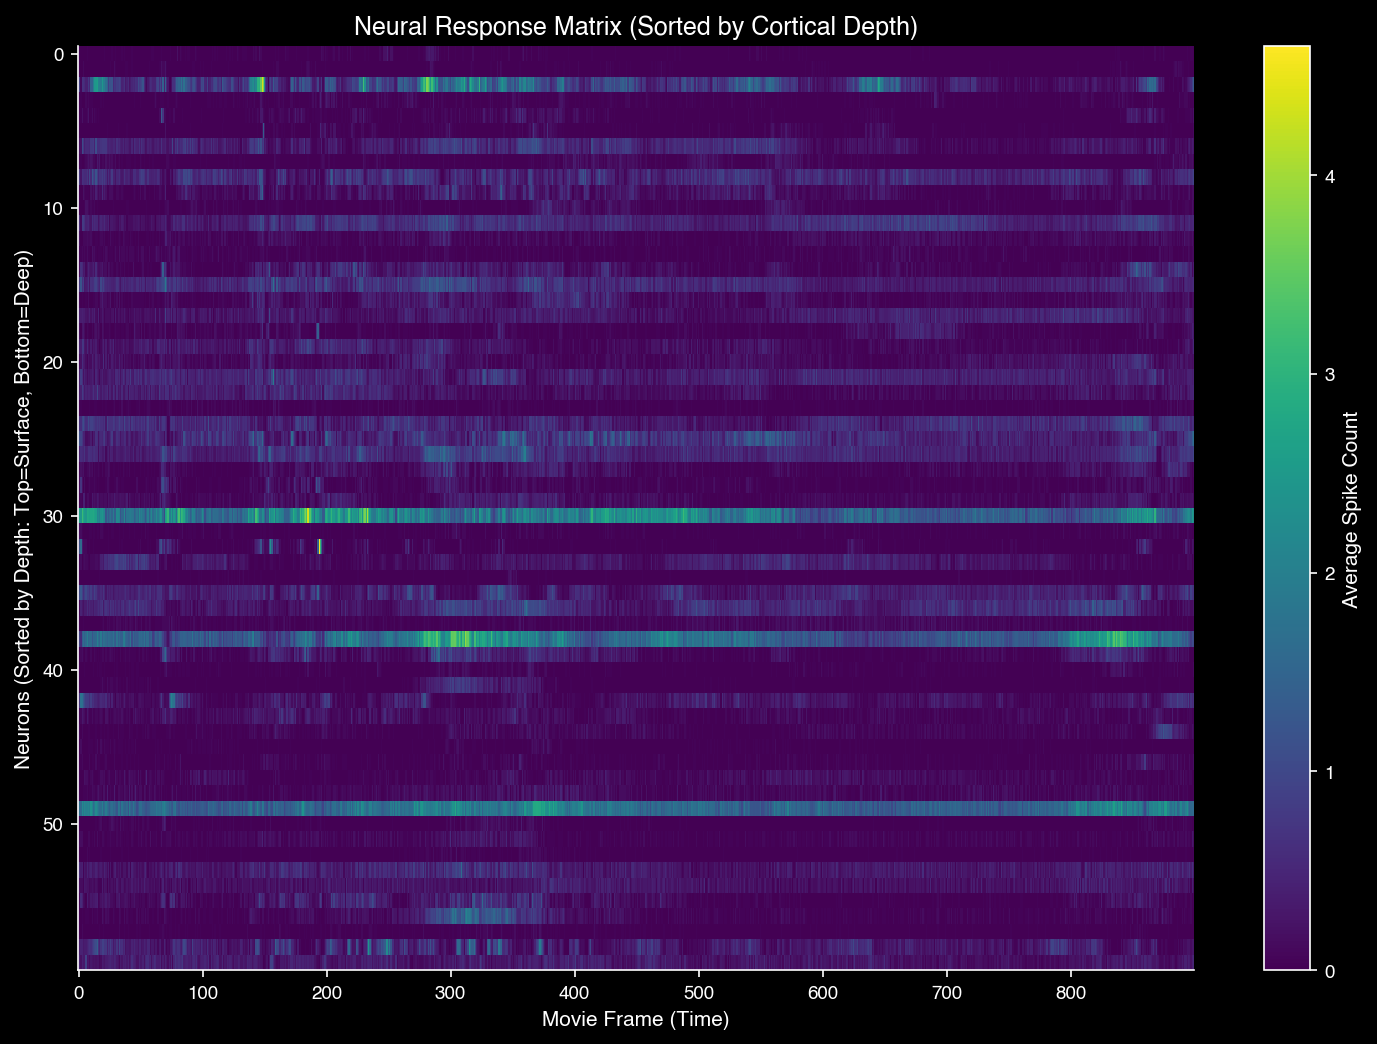

In [18]:
if 'natural_movie_one' in session.stimulus_names and not visp_units.empty:
    sorted_units = visp_units.sort_values(by="probe_vertical_position", ascending=False)

    print("--- Depth Sorting ---")
    print(f"Shallowest Unit: {sorted_units.iloc[0]['probe_vertical_position']} um")
    print(f"Deepest Unit: {sorted_units.iloc[-1]['probe_vertical_position']} um")

    sorted_response_matrix = average_response_matrix[sorted_units.index]

    plt.figure(figsize=(12, 8))
    plt.imshow(sorted_response_matrix.T, aspect='auto', cmap='viridis', interpolation='none')

    plt.xlabel("Movie Frame (Time)")
    plt.ylabel("Neurons (Sorted by Depth: Top=Surface, Bottom=Deep)")
    plt.title("Neural Response Matrix (Sorted by Cortical Depth)")
    plt.colorbar(label="Average Spike Count")
    plt.show()

### Step 7: Probe Trajectories & 3D Locations
Visualize the physical location of the probes and recorded units in the mouse brain (CCF Coordinates).

--- Session Probes Metadata ---


,description,location,sampling_rate,lfp_sampling_rate,has_lfp_data
id,,,,,
810755797,probeA,See electrode locations,29999.954846,1249.998119,True
810755799,probeB,See electrode locations,29999.906318,1249.996097,True
810755801,probeC,See electrode locations,29999.985470,1249.999395,True
810755803,probeD,See electrode locations,29999.908100,1249.996171,True
810755805,probeE,See electrode locations,29999.985679,1249.999403,True
810755807,probeF,See electrode locations,30000.028033,1250.001168,True


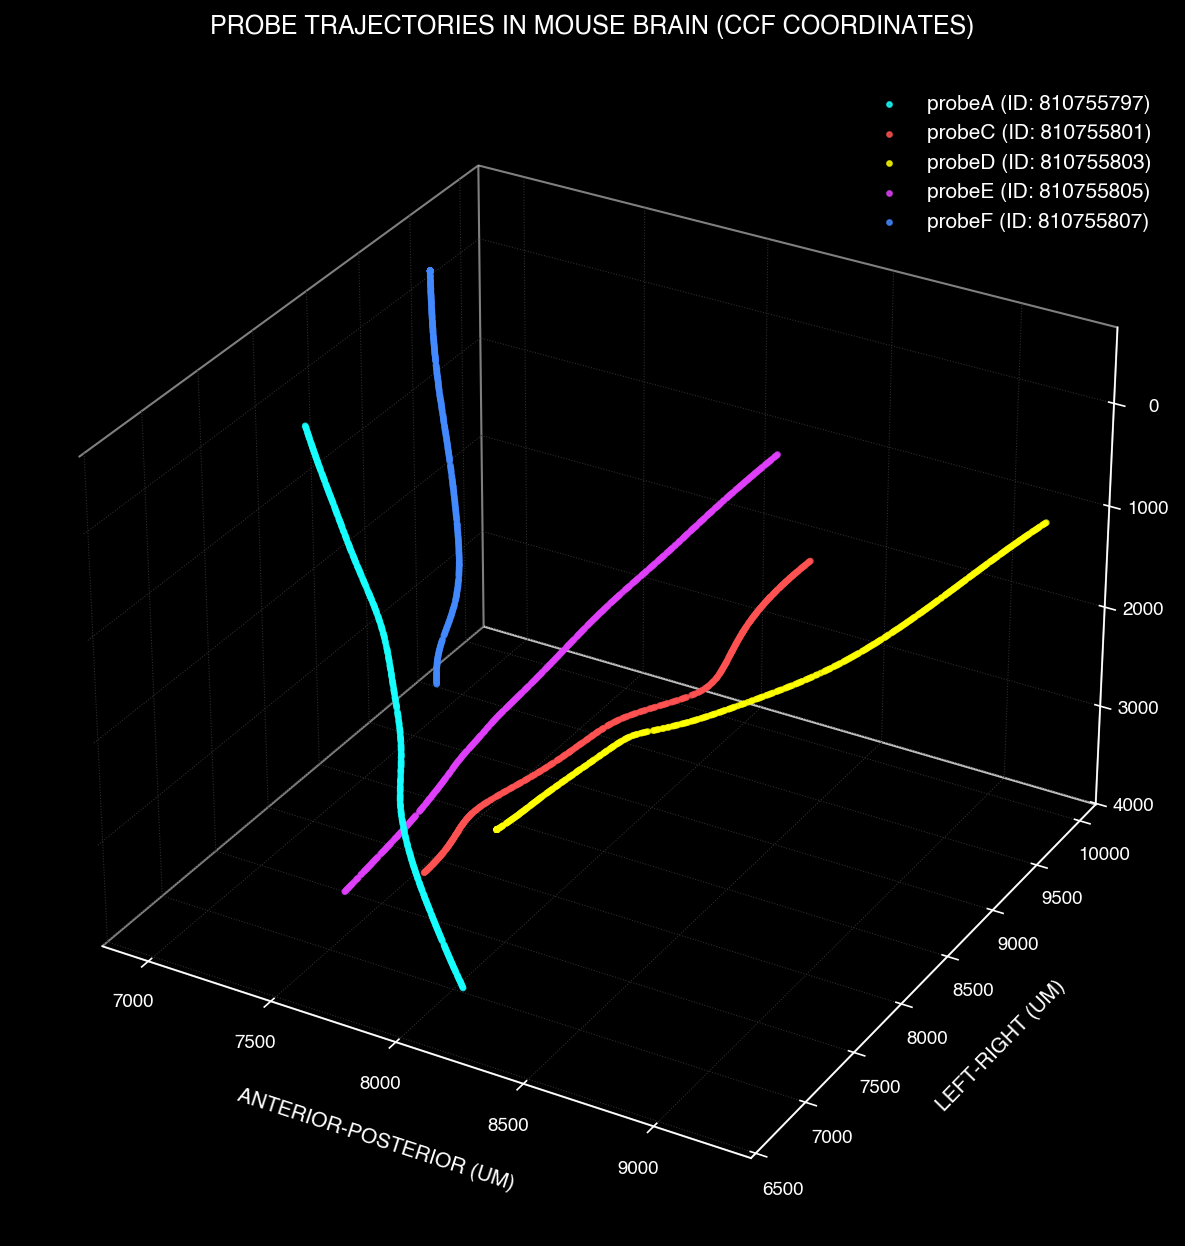

In [19]:
print("--- Session Probes Metadata ---")
display(session.probes)

if 'anterior_posterior_ccf_coordinate' in session.channels.columns:
    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Architectural 3D Style
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor(viz_style.WHITE)
    ax.yaxis.pane.set_edgecolor(viz_style.WHITE)
    ax.zaxis.pane.set_edgecolor(viz_style.WHITE)
    ax.grid(True, linestyle=':', linewidth=0.5, color='#333333')

    colors = [viz_style.CYAN, viz_style.GREEN, viz_style.RED, viz_style.YELLOW, viz_style.PURPLE, viz_style.BLUE]

    for i, (probe_id, probe_info) in enumerate(session.probes.iterrows()):
        probe_channels = session.channels[session.channels['probe_id'] == probe_id]
        
        valid_channels = probe_channels.dropna(subset=['anterior_posterior_ccf_coordinate', 'dorsal_ventral_ccf_coordinate', 'left_right_ccf_coordinate'])
        
        if not valid_channels.empty:
            x = valid_channels['anterior_posterior_ccf_coordinate']
            y = valid_channels['left_right_ccf_coordinate']
            z = valid_channels['dorsal_ventral_ccf_coordinate']
            
            color = colors[i % len(colors)]
            ax.scatter(x, y, z, label=f"{probe_info['description']} (ID: {probe_id})", s=5, color=color, alpha=0.8)

    ax.set_xlabel('ANTERIOR-POSTERIOR (UM)', labelpad=10, color=viz_style.WHITE)
    ax.set_ylabel('LEFT-RIGHT (UM)', labelpad=10, color=viz_style.WHITE)
    ax.set_zlabel('DORSAL-VENTRAL (UM)', labelpad=10, color=viz_style.WHITE)
    
    ax.tick_params(axis='x', colors=viz_style.WHITE)
    ax.tick_params(axis='y', colors=viz_style.WHITE)
    ax.tick_params(axis='z', colors=viz_style.WHITE)
    
    ax.invert_zaxis() 
    
    ax.set_title('PROBE TRAJECTORIES IN MOUSE BRAIN (CCF COORDINATES)', pad=20, color=viz_style.WHITE)
    ax.legend(frameon=False, labelcolor=viz_style.WHITE)
    plt.show()
else:
    print("CCF coordinates are not available for this session.")

Plotting 717 units with location data...


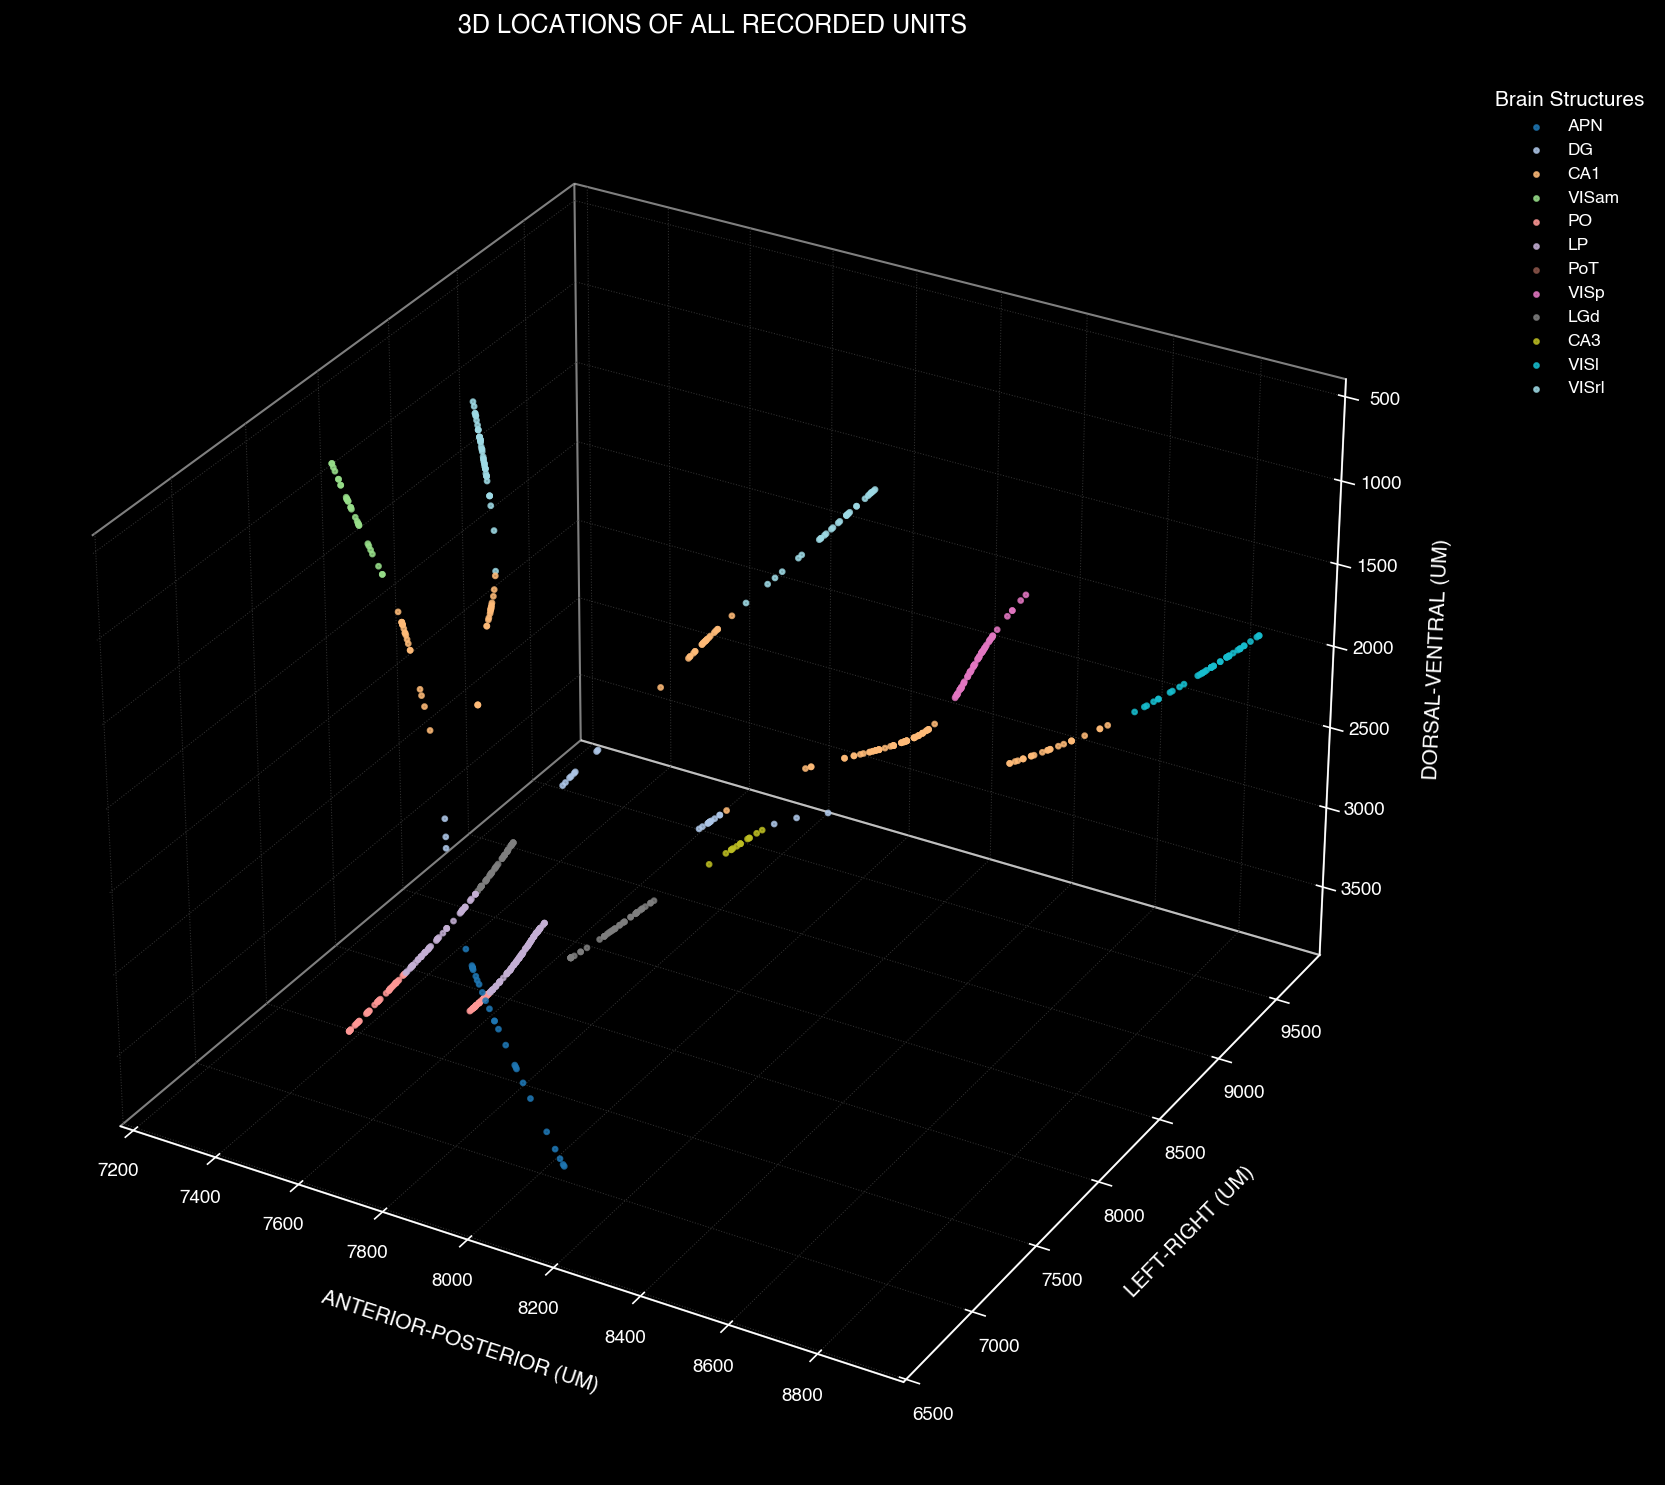

In [20]:
from mpl_toolkits.mplot3d import Axes3D

units_with_loc = session.units.dropna(subset=[
    'anterior_posterior_ccf_coordinate', 
    'dorsal_ventral_ccf_coordinate', 
    'left_right_ccf_coordinate'
])

print(f"Plotting {len(units_with_loc)} units with location data...")

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Architectural 3D Style
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor(viz_style.WHITE)
ax.yaxis.pane.set_edgecolor(viz_style.WHITE)
ax.zaxis.pane.set_edgecolor(viz_style.WHITE)
ax.grid(True, linestyle=':', linewidth=0.5, color='#333333')

structures = units_with_loc['ecephys_structure_acronym'].unique()
# Use tab20 but ensure it looks okay on black, or use custom cycle
colors = plt.cm.tab20(np.linspace(0, 1, len(structures)))

for i, structure in enumerate(structures):
    structure_units = units_with_loc[units_with_loc['ecephys_structure_acronym'] == structure]
    
    x = structure_units['anterior_posterior_ccf_coordinate']
    y = structure_units['left_right_ccf_coordinate']
    z = structure_units['dorsal_ventral_ccf_coordinate']
    
    ax.scatter(x, y, z, label=structure, s=5, alpha=0.8, color=colors[i])

ax.set_xlabel('ANTERIOR-POSTERIOR (UM)', labelpad=10, color=viz_style.WHITE)
ax.set_ylabel('LEFT-RIGHT (UM)', labelpad=10, color=viz_style.WHITE)
ax.set_zlabel('DORSAL-VENTRAL (UM)', labelpad=10, color=viz_style.WHITE)

ax.tick_params(axis='x', colors=viz_style.WHITE)
ax.tick_params(axis='y', colors=viz_style.WHITE)
ax.tick_params(axis='z', colors=viz_style.WHITE)

ax.invert_zaxis()

ax.set_title('3D LOCATIONS OF ALL RECORDED UNITS', pad=20, color=viz_style.WHITE)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', title="Brain Structures", frameon=False, labelcolor=viz_style.WHITE)
# Fix legend title color
ax.get_legend().get_title().set_color(viz_style.WHITE)

plt.tight_layout()
plt.show()